In [1]:
import pandas as pd

df = pd.read_csv("../data/cleaned/final_dataset.csv")

df.head()

,encounter_id,patient_nbr,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,department_Neurology,department_Surgery,"location_Houston, TX","location_Los Angeles, CA","location_New York, NY","location_Phoenix, AZ",readmitted_>30,readmitted_NO,diabetesMed_Yes,change_No
0,149190,55629189,[10-20),1,1,7,3,59,0,18,...,False,False,False,False,True,False,True,False,True,False
1,64410,86047875,[20-30),1,1,7,2,11,5,13,...,False,False,False,False,True,False,False,True,True,True
2,500364,82442376,[30-40),1,1,7,2,44,1,16,...,True,False,False,False,False,False,False,True,True,False
3,16680,42519267,[40-50),1,1,7,1,51,0,8,...,False,False,False,False,False,False,False,True,True,False
4,35754,82637451,[50-60),2,1,2,3,31,6,16,...,False,False,True,False,False,False,True,False,True,True


In [2]:
print(df.columns)

Index(['encounter_id', 'patient_nbr', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'doctor_id', 'admission_date',
       'bed_occupancy', 'patient_satisfaction', 'length_of_stay', 'race_Asian',
       'race_Caucasian', 'race_Hispanic', 'race_Other', 'gender_Male',
       'gender_Unkn

In [3]:
print(df["admission_date"].head())

0    2007-10-03
1    2005-11-13
2    2002-04-11
3    2003-06-26
4    2002-08-19
Name: admission_date, dtype: object


In [4]:
df["admission_date"] = pd.to_datetime(
    df["admission_date"],
    errors="coerce"
)

df["admission_date"].head()

0   2007-10-03
1   2005-11-13
2   2002-04-11
3   2003-06-26
4   2002-08-19
Name: admission_date, dtype: datetime64[ns]

In [5]:
df["admission_date"].isnull().sum()


0

In [7]:
df.duplicated().sum()
df = df.drop_duplicates()

In [8]:
daily = (
    df.groupby("admission_date")
      .size()
      .reset_index(name="Admissions")
)

daily.head()

,admission_date,Admissions
0,1999-01-01,34
1,1999-01-02,30
2,1999-01-03,24
3,1999-01-04,28
4,1999-01-05,31


In [9]:
daily = daily.set_index("admission_date")

all_dates = pd.date_range(
    start=daily.index.min(),
    end=daily.index.max(),
    freq="D"
)

daily = daily.reindex(
    all_dates,
    fill_value=0
)

daily.index.name = "Date"

daily.head()

,Admissions
Date,
1999-01-01,34
1999-01-02,30
1999-01-03,24
1999-01-04,28
1999-01-05,31


In [10]:
weekly = daily.resample("W").sum()

weekly.head()


,Admissions
Date,
1999-01-03,88
1999-01-10,183
1999-01-17,191
1999-01-24,179
1999-01-31,157


In [11]:
monthly = daily.resample("M").sum()

monthly.head()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7596\1971579406.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = daily.resample("M").sum()


,Admissions
Date,
1999-01-31,798
1999-02-28,724
1999-03-31,778
1999-04-30,783
1999-05-31,851


In [12]:
daily.to_csv("../data/cleaned/daily_admissions.csv")
weekly.to_csv("../data/cleaned/weekly_admissions.csv")
monthly.to_csv("../data/cleaned/monthly_admissions.csv")

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

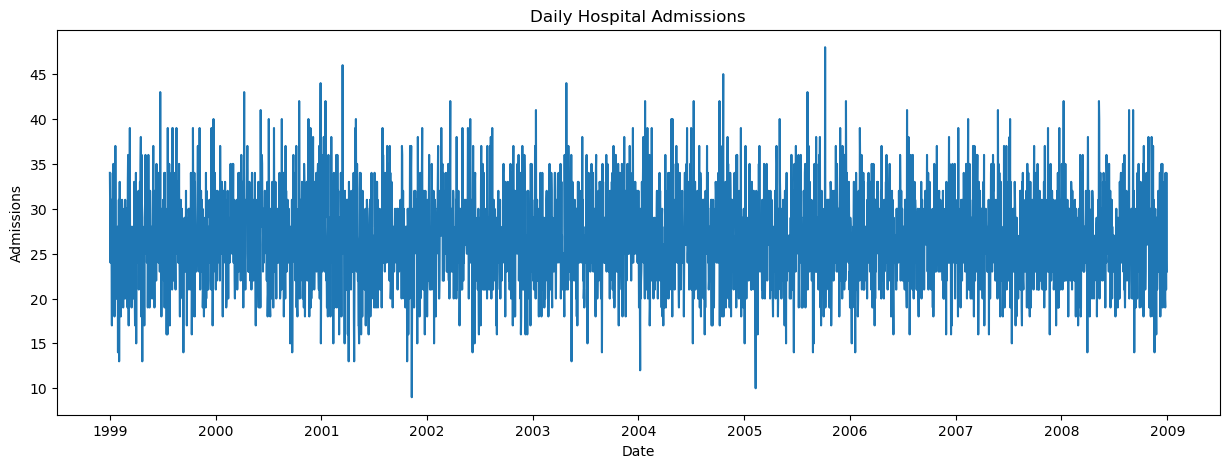

In [14]:
plt.figure(figsize=(15,5))

plt.plot(daily.index, daily["Admissions"])

plt.title("Daily Hospital Admissions")
plt.xlabel("Date")
plt.ylabel("Admissions")

plt.show()


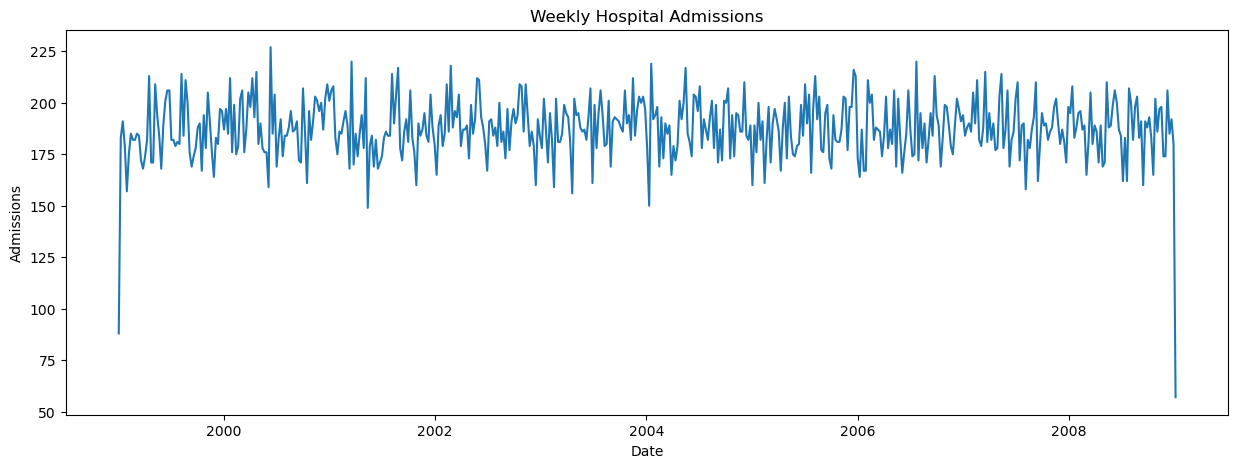

In [15]:
plt.figure(figsize=(15,5))

plt.plot(weekly.index, weekly["Admissions"])

plt.title("Weekly Hospital Admissions")
plt.xlabel("Date")
plt.ylabel("Admissions")

plt.show()

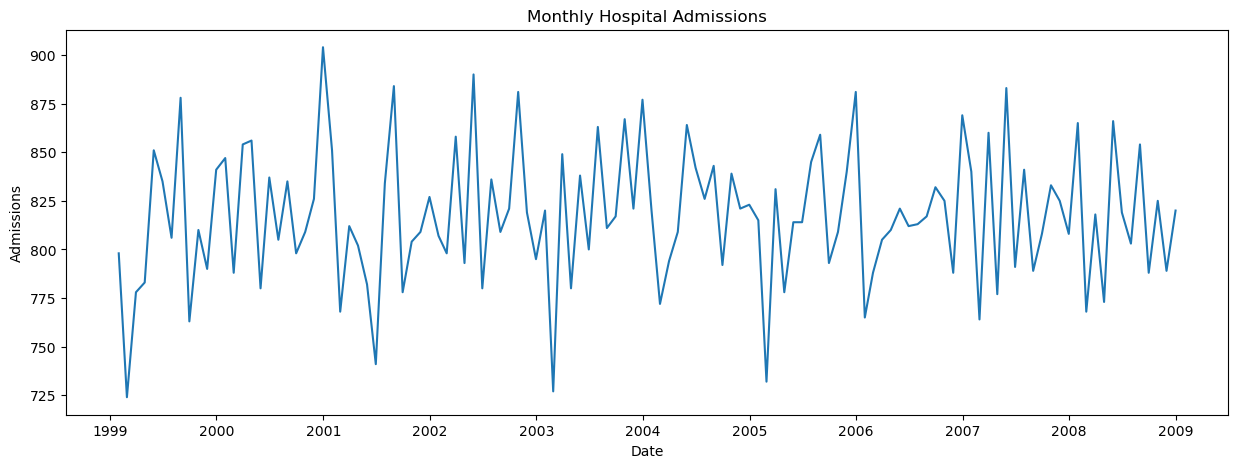

In [16]:
plt.figure(figsize=(15,5))

plt.plot(monthly.index, monthly["Admissions"])

plt.title("Monthly Hospital Admissions")
plt.xlabel("Date")
plt.ylabel("Admissions")

plt.show()


In [17]:
daily["DayOfWeek"] = daily.index.day_name()

daily.head()

,Admissions,DayOfWeek
Date,,
1999-01-01,34,Friday
1999-01-02,30,Saturday
1999-01-03,24,Sunday
1999-01-04,28,Monday
1999-01-05,31,Tuesday


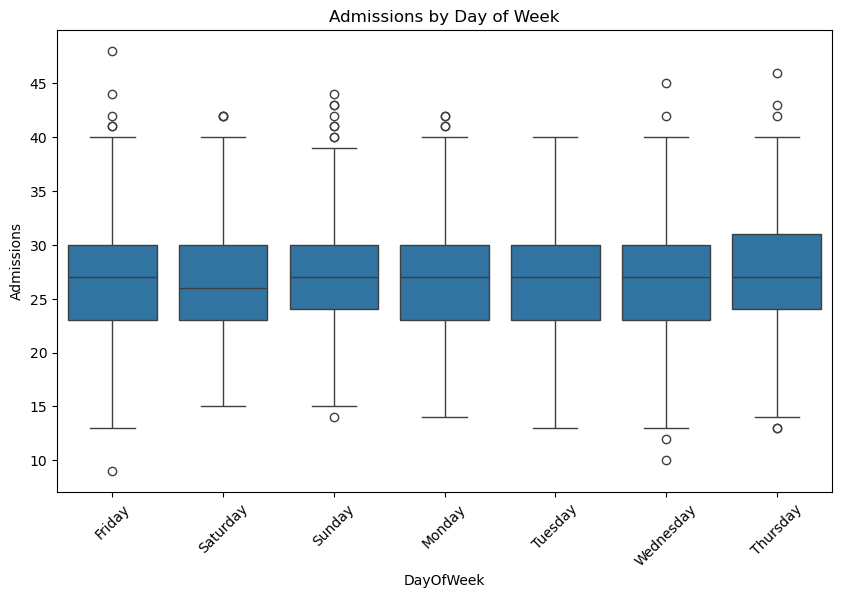

In [18]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="DayOfWeek",
    y="Admissions",
    data=daily
)

plt.xticks(rotation=45)

plt.title("Admissions by Day of Week")

plt.show()

In [19]:
daily["Month"] = daily.index.month_name()

daily.head()

,Admissions,DayOfWeek,Month
Date,,,
1999-01-01,34,Friday,January
1999-01-02,30,Saturday,January
1999-01-03,24,Sunday,January
1999-01-04,28,Monday,January
1999-01-05,31,Tuesday,January


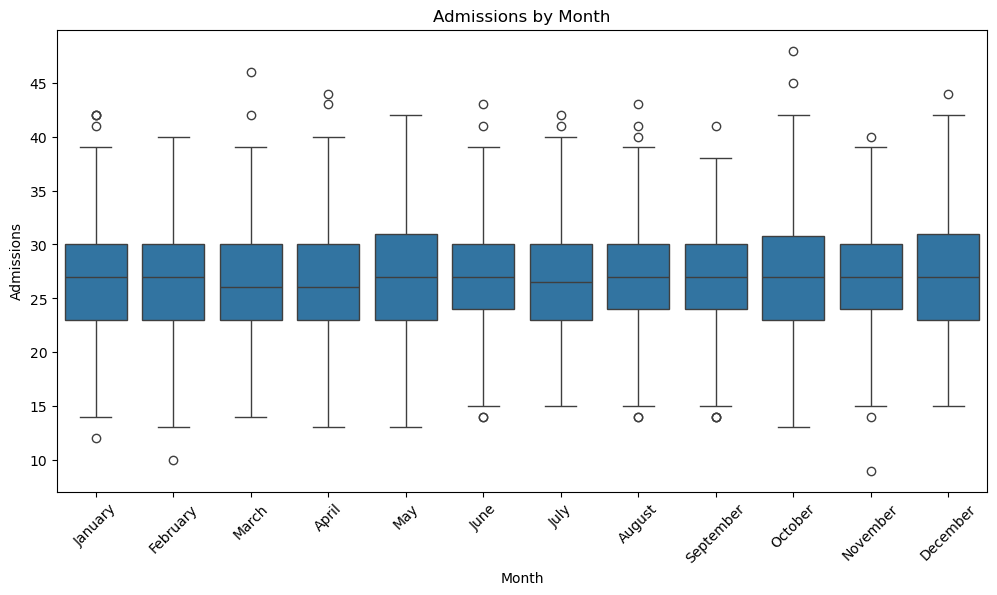

In [20]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="Month",
    y="Admissions",
    data=daily
)

plt.xticks(rotation=45)

plt.title("Admissions by Month")

plt.show()

In [21]:
daily["7_day_avg"] = (
    daily["Admissions"]
    .rolling(7)
    .mean()
)

daily["30_day_avg"] = (
    daily["Admissions"]
    .rolling(30)
    .mean()
)

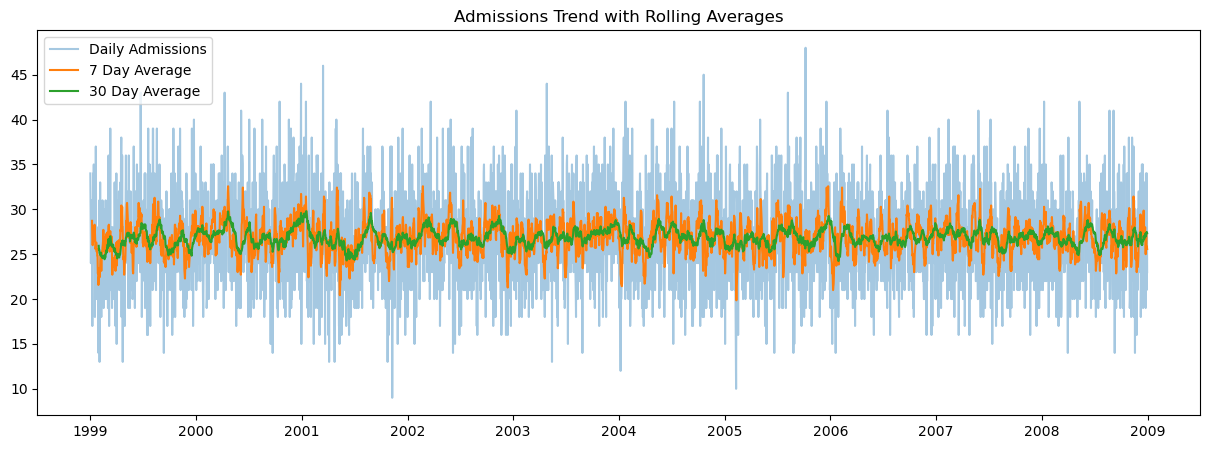

In [22]:
plt.figure(figsize=(15,5))

plt.plot(
    daily.index,
    daily["Admissions"],
    alpha=0.4,
    label="Daily Admissions"
)

plt.plot(
    daily.index,
    daily["7_day_avg"],
    label="7 Day Average"
)

plt.plot(
    daily.index,
    daily["30_day_avg"],
    label="30 Day Average"
)

plt.legend()

plt.title("Admissions Trend with Rolling Averages")

plt.show()

In [23]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(daily["Admissions"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -36.82837132851481
p-value: 0.0


In [24]:
from statsmodels.tsa.stattools import kpss

kpss_result = kpss(
    daily["Admissions"],
    regression="c"
)

print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])

KPSS Statistic: 0.053112086574101075
p-value: 0.1


C:\Users\lenovo\AppData\Local\Temp\ipykernel_7596\3647730205.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(


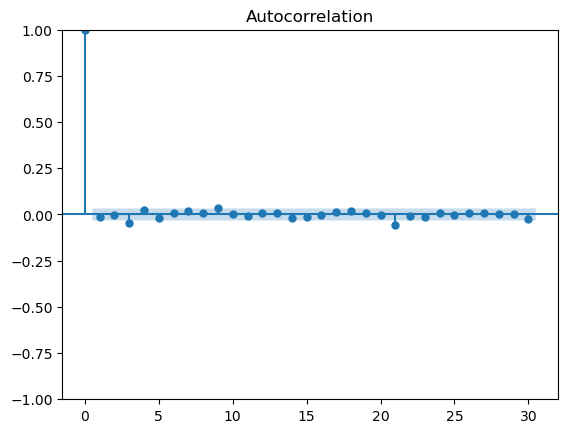

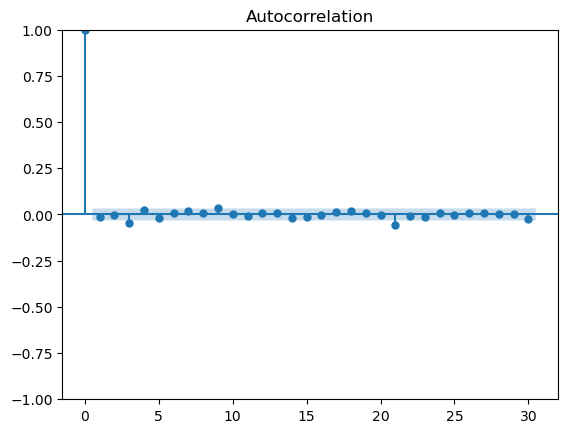

In [25]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    daily["Admissions"],
    lags=30
)

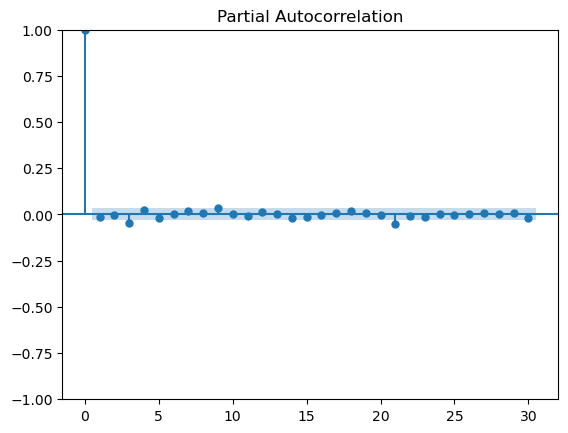

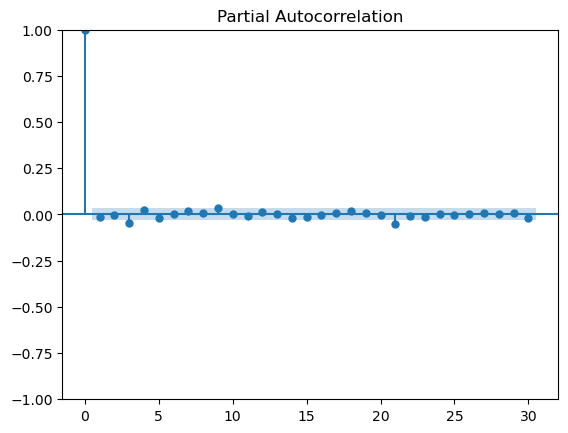

In [26]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(
    daily["Admissions"],
    lags=30
)

# Summary

## Data Preparation

- Converted the admission_date column to datetime format.
- Removed duplicate records.
- Generated daily, weekly, and monthly admission datasets.

## Trend Analysis

Daily hospital admissions remained relatively stable throughout the observation period with minor fluctuations and occasional spikes.

## Seasonality

A weekly seasonal pattern is expected in hospital admissions.

Recommended seasonal period:

s = 7

## Outliers

Potential outliers were identified and retained because admission spikes may represent real healthcare events.

## Stationarity

ADF Test:

ADF Statistic = -36.83

p-value = 0.0

Conclusion:
The series is stationary.

KPSS Test:

KPSS Statistic = 0.0531

p-value = 0.1

Conclusion:
The series is stationary.

## Suggested ARIMA Parameters

p = 1

d = 0

q = 1

Seasonal period = 7